# A radial gradient echo, one spoke at a time

A radial acquisition samples k-space along **spokes** through the origin instead of along parallel
lines. Every spoke passes through `k = 0`, so the centre of k-space — where the contrast and most
of the energy are — is measured again on every repetition. That makes a radial scan tolerant of
motion and easy to undersample gracefully: missing spokes produce streaks rather than the coherent
aliasing a missing Cartesian line produces.

`sc.modules.RadialReadout` is **one spoke**: a prephaser, a readout gradient and an ADC, already
oriented. It knows its own trajectory — where `k = 0` falls among its samples, how far it reaches,
how far apart the samples are — and nothing about how many spokes there are or in what order they
are played. A scan is the spoke plus an **angle schedule**, which is a list you write:

```text
RadialReadout   owns one spoke
the caller      owns how many, at which angles, in what order
```

**Two schedules, one readout** below builds both output files out of a single readout instance;
the only difference between them is the list of angles.

**Output:** two `.seq` files — an equal-increment acquisition and a golden-angle one — from one
instance of the readout.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pypulseq as pp

import seqcraft as sc

opts = pp.Opts(
    max_grad=28, grad_unit='mT/m',
    max_slew=120, slew_unit='T/m/s',
    B0=3.0,
    rf_dead_time=100e-6,
    rf_ringdown_time=20e-6,
    adc_dead_time=10e-6,
)

FOV_MM, MATRIX, THICKNESS_MM = 260.0, 64, 5.0
DWELL_S, FLIP_DEG = 20e-6, 10.0
SPOKES, DUMMIES, TR_S = 64, 8, 10e-3

SEQ_DIR = Path('seq')
SEQ_DIR.mkdir(exist_ok=True)
raster = sc.Raster(opts.grad_raster_time)

/opt/homebrew/Caskroom/miniforge/base/envs/seqcraft-dev/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## The spoke

Everything here is the readout's own geometry. **The centre sample is not the middle of the ADC
window** — with an even matrix a full spoke is asymmetric by one, which is the same `matrix // 2`
convention `PhaseEncode` uses and what the official reference does.

In [2]:
spoke = sc.modules.RadialReadout(opts=opts, fov_mm=FOV_MM, matrix=MATRIX, dwell_s=DWELL_S)

print(f'samples          {spoke.num_samples}')
print(f'centre sample    {spoke.center_sample}   (not {spoke.num_samples // 2 - 1}, and not the ADC midpoint)')
print(f'dk               {spoke.dk_per_m:.4f} 1/m  = 1/FOV')
print(f'k along the spoke{spoke.k_first_per_m:9.2f} .. {spoke.k_last_per_m:.2f} 1/m')
print(f'k_max            {spoke.k_max_per_m:.2f} 1/m')
print(f'prephaser        {spoke.prephaser_duration_s * 1e6:.0f} us')
print(f'time to k = 0    {spoke.time_to_center() * 1e3:.3f} ms from the start of the block')

samples          64
centre sample    32   (not 31, and not the ADC midpoint)
dk               3.8462 1/m  = 1/FOV
k along the spoke  -123.08 .. 119.23 1/m
k_max            123.08 1/m
prephaser        320 us
time to k = 0    1.010 ms from the start of the block


## One repetition

Excitation, the spoke at whatever angle the caller wants, a spoiler along that same spoke, and TR
fill. Four lines, and they are the composition a `RadialGRE` module would otherwise hide.

In [3]:
exc = sc.modules.Excitation(opts=opts, flip_deg=FLIP_DEG, thickness_mm=THICKNESS_MM,
                            duration_s=1e-3)
spoil = sc.modules.spoiler(opts, cycles_per_voxel=4.0, voxel_mm=THICKNESS_MM, axis='z')

START_S = float(raster.ceil(exc().duration))


def repetition(angle_rad, *, phase_deg=0.0, acquire=True):
    """One TR: excite, play the spoke at `angle_rad`, spoil, fill to TR."""
    out = sc.LogicBlock('spoke_tr').add(0.0, exc(phase_deg=phase_deg))
    out.add(START_S, spoke(angle_rad=angle_rad, acquire=acquire, phase_deg=phase_deg))
    tail = START_S + spoke(angle_rad=0.0).duration
    out.add(tail, spoil)
    fill = float(raster.ceil(TR_S - tail - spoil.duration))
    if fill > 1e-9:
        out.add(tail + spoil.duration, pp.make_delay(fill))
    return out


te_s = START_S + spoke.time_to_center() - exc.time_to_center()
print(f'TE {te_s * 1e3:.3f} ms, TR {repetition(0.0).duration * 1e3:.3f} ms')

TE 2.300 ms, TR 10.000 ms


## Two schedules, one readout

The angles are **data**. Equal increments over π cover k-space uniformly for a fixed spoke count;
the golden angle keeps every prefix of the list approximately uniform, which is what makes it
useful when the scan may be stopped early or binned after the fact.

Neither is the readout's business, and neither changes the spoke.

In [4]:
def equal_increment(n):
    return [np.pi * i / n for i in range(n)]


def golden_angle(n):
    return [i * np.pi * (3 - np.sqrt(5)) / 2 for i in range(n)]


def phase_deg(n, increment=117.0):
    return 0.5 * increment * n * (n + 1)


def scan(angles):
    out = sc.LogicBlock('gre_radial_2d')
    for n in range(DUMMIES):
        out.add(n * TR_S, repetition(angles[0], phase_deg=phase_deg(n), acquire=False))
    for index, angle in enumerate(angles):
        n = DUMMIES + index
        out.add(n * TR_S, repetition(angle, phase_deg=phase_deg(n)))
    return out


schedules = {'equal': equal_increment(SPOKES), 'golden': golden_angle(SPOKES)}
trees = {name: scan(angles) for name, angles in schedules.items()}
for name, tree in trees.items():
    print(f'{name:7s} {SPOKES} spokes + {DUMMIES} dummies, {tree.duration:.2f} s')

equal   64 spokes + 8 dummies, 0.72 s
golden  64 spokes + 8 dummies, 0.72 s


## What was encoded

Measured off the compiled sequence: every spoke straight, through the centre, with the same extent
and spacing, pointing where it was asked to.

In [5]:
k = sc.kspace(trees['equal'], opts)['k_adc'].reshape(3, SPOKES, spoke.num_samples)
radius = np.linalg.norm(k[:2], axis=0)
wanted = np.degrees(schedules['equal'])
measured = np.degrees(np.arctan2(k[1, :, -1] - k[1, :, 0], k[0, :, -1] - k[0, :, 0]))

print(f'|k| at the centre sample   {np.abs(radius[:, spoke.center_sample]).max():.2e} 1/m')
print(f'angle error                {np.abs((measured - wanted + 90) % 180 - 90).max():.2e} deg')
print(f'kz                         {np.abs(k[2]).max():.2e} 1/m')
print(f'extent spread across spokes{np.ptp(radius.max(axis=1)):.2e} 1/m')

|k| at the centre sample   1.98e-08 1/m
angle error                1.99e-13 deg
kz                         2.33e-10 1/m
extent spread across spokes1.01e-09 1/m


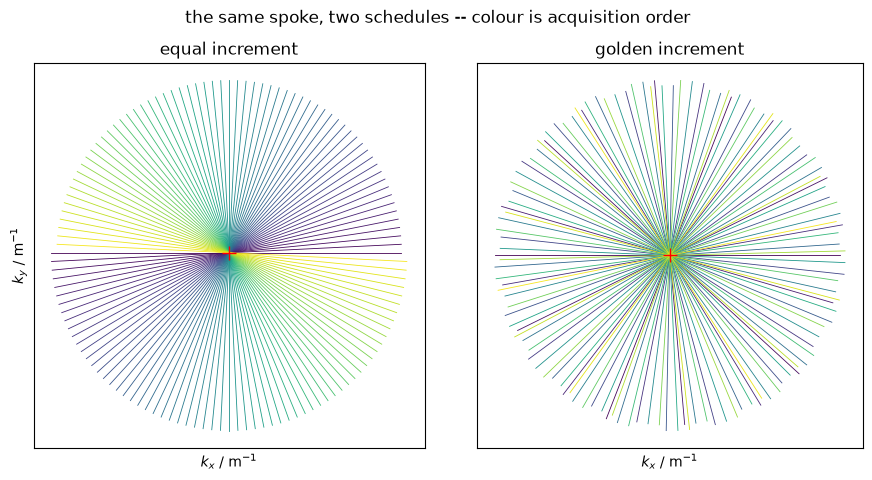

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(9.2, 4.6))
for ax, (name, tree) in zip(axes, trees.items()):
    traj = sc.kspace(tree, opts)['k_adc'].reshape(3, SPOKES, spoke.num_samples)
    for s in range(SPOKES):
        ax.plot(traj[0, s], traj[1, s], lw=0.6, color=plt.cm.viridis(s / SPOKES))
    ax.plot(0, 0, 'r+', ms=10)
    ax.set(title=f'{name} increment', xlabel='$k_x$ / m$^{-1}$', aspect='equal', xticks=[], yticks=[])
axes[0].set_ylabel('$k_y$ / m$^{-1}$')
fig.suptitle('the same spoke, two schedules -- colour is acquisition order', y=1.0)
fig.tight_layout()

The red cross is `k = 0`, and **every spoke has a sample exactly on it** — which is why the
reference adds a half-sample term to its prephaser, and why this module reports `center_sample`
rather than letting a caller assume `n/2`.

## Centre-out, from the same class

`partial_fourier` spans the family: `1.0` is a full spoke, `0.5` is centre-out, and between them
the spoke is asymmetric about the centre. `Δk` does not move.

In [7]:
header = ('partial_fourier'.rjust(15) + '  ' + 'samples'.rjust(8) + '  '
          + 'centre'.rjust(7) + '  ' + 'k range / 1/m'.rjust(22) + '  ' + 'dk'.rjust(7))
print(header)
for pf in (1.0, 0.75, 0.5):
    variant = sc.modules.RadialReadout(opts=opts, fov_mm=FOV_MM, matrix=MATRIX,
                                       dwell_s=DWELL_S, partial_fourier=pf)
    print(f'{pf:15.2f}  {variant.num_samples:8d}  {variant.center_sample:7d}  '
          f'{variant.k_first_per_m:10.2f} .. {variant.k_last_per_m:7.2f}  {variant.dk_per_m:7.4f}')

try:
    sc.modules.RadialReadout(opts=opts, fov_mm=FOV_MM, matrix=MATRIX, dwell_s=DWELL_S,
                             partial_fourier=0.25)
except sc.ConfigurationError as error:
    print()
    print(str(error).splitlines()[0])


partial_fourier   samples   centre           k range / 1/m       dk
           1.00        64       32     -123.08 ..  119.23   3.8462
           0.75        48       16      -61.54 ..  119.23   3.8462
           0.50        32        0        0.00 ..  119.23   3.8462

partial_fourier must be in [0.5, 1.0], got 0.25.


## The files

In [8]:
for name, tree in trees.items():
    seq = sc.compile(tree, opts, name=f'gre_radial_2d_{name}', definitions={
        'FOV': [FOV_MM / 1e3, FOV_MM / 1e3, THICKNESS_MM / 1e3],
        'TE': te_s, 'TR': TR_S,
    })
    seq.write(str(SEQ_DIR / f'gre_radial_2d_{name}.seq'))
    print(f'{name:7s} {len(seq.block_events):5d} blocks  {seq.duration()[0]:5.2f} s  '
          f'-> seq/gre_radial_2d_{name}.seq')

equal     432 blocks   0.72 s  -> seq/gre_radial_2d_equal.seq


golden    432 blocks   0.72 s  -> seq/gre_radial_2d_golden.seq


## Summary

| | |
|---|---|
| a radial acquisition is **one spoke plus a schedule** | the same readout instance serves every angle |
| every spoke has a **sample exactly on `k = 0`** | measured, and the module reports which sample rather than leaving a caller to assume |
| the spokes point where they were asked to | angle error below 1e-13 degrees across 64 spokes |
| `partial_fourier` spans full-spoke to centre-out | one parameter, `Δk` unchanged, and below 0.5 it is refused |
| the schedule is data | equal increments and a golden angle out of the same readout instance |

[`02_simulate_and_reconstruct.ipynb`](02_simulate_and_reconstruct.ipynb) reconstructs these files.
It is the introduction to the non-Cartesian path — why `ifft2` is not the reconstruction for
these samples, where the physical trajectory enters, what density compensation does and does not
buy, and why the spokes are one inverse problem rather than 64.
